# 14 — Neural Network Math: Gradient Descent & Backpropagation

**Prerequisite:** notebook 09. **Read alongside:** notebook 15 (components).

I NN overview we said "backpropagation is just gradient descent on a big function."
This notebook unpacks that sentence fully — the linear algebra, the calculus,
and the **loss surface** picture that makes it all click. If you've ever
wondered *what the optimiser is actually doing*, this is the answer. Pair it
with notebook 15 (activations, loss functions, optimisers) for the full
picture.

## What you'll understand after this notebook

1. The three math objects a neural net is made of: **scalars, vectors, and the
 gradient** — and why the gradient points "uphill on the loss".
2. **Gradient descent** as "walk downhill on the loss surface" — with plots of
 the surface itself.
3. What the **learning rate** actually does, and the failure modes (too high →
 divergence, too low → crawl) shown as trajectories.
4. **Backpropagation** as the chain rule, applied layer-by-layer — derived by
 hand for a 2-layer net so it's not magic.
5. Why **feature scaling** (§1.2, notebook 09 §6) makes the loss surface
 well‑conditioned and gradient descent converge.

## How this notebook is organised

```mermaid
flowchart TD
 M["The math objects:<br/>scalars, vectors, dot products, the gradient"] --> GD
 GD["Gradient descent:<br/>walk downhill on the loss surface"] --> LR
 LR["Learning rate:<br/>too high / too low / just right"] --> BP
 BP["Backpropagation:<br/>the chain rule, layer by layer"] --> SC
 SC["Why scaling matters:<br/>conditioning the loss surface"]
```

## 1. The math objects under every neural net

Everything in deep learning is built from four objects. Get them straight and
the rest is detail.

### 1.1 Scalars, vectors, matrices, tensors

| Object | Example | In a neural net |
|---|---|---|
| **Scalar** (0‑tensor) | a single number, e.g. `0.7` | a bias $b$, a loss value, a learning rate $\eta$ |
| **Vector** (1‑tensor) | a list of numbers, e.g. `[0.2, -1.3, 0.8]` | one input row $x$, one layer's activations, the bias vector |
| **Matrix** (2‑tensor) | a 2D grid | a layer's **weights** $W$ — each row is one neuron's weights |
| **Tensor** (n‑tensor) | an n‑D grid | a batch of images (batch × height × width × channels) |

We'll mostly need **vectors and matrices** in this notebook.

### 1.2 The dot product — the only operation a neuron does

A single neuron computes a **weighted sum** via the dot product, then adds a
bias and applies an activation:

$$z = w \cdot x + b = \sum_i w_i x_i + b, \qquad a = \sigma(z)$$

That's it. A whole layer of $m$ neurons is the same thing stacked — a
**matrix–vector product**:

$$z = Wx + b \quad (W \in \mathbb{R}^{m \times n},\ x \in \mathbb{R}^{n},\ z \in \mathbb{R}^{m})$$

> **Why this matters:** every "deep learning" architecture — MLPs, CNNs,
> Transformers — is, at its core, a pile of dot products with nonlinearities
> between them. There is no other operation. The complexity lives in *how many*
> and *how they're wired*.

### 1.3 The gradient — "uphill on the loss"

The **gradient** $\nabla L$ is a vector of partial derivatives: one entry per
parameter, each saying "if I nudge this parameter up a tiny bit, by how much
does the loss go up?"

$$\nabla L = \left(\frac{\partial L}{\partial w_1},\ \frac{\partial L}{\partial w_2},\ \dots,\ \frac{\partial L}{\partial w_p}\right)$$

Three facts that make everything else click:

1. The gradient points **uphill** — in the direction of *steepest increase* of $L$.
2. So $-\nabla L$ points **downhill** — toward lower loss.
3. Its magnitude $\lVert \nabla L \rVert$ is the **slope** — flat regions have
 tiny gradients (learning stalls); steep regions have large ones (big steps).

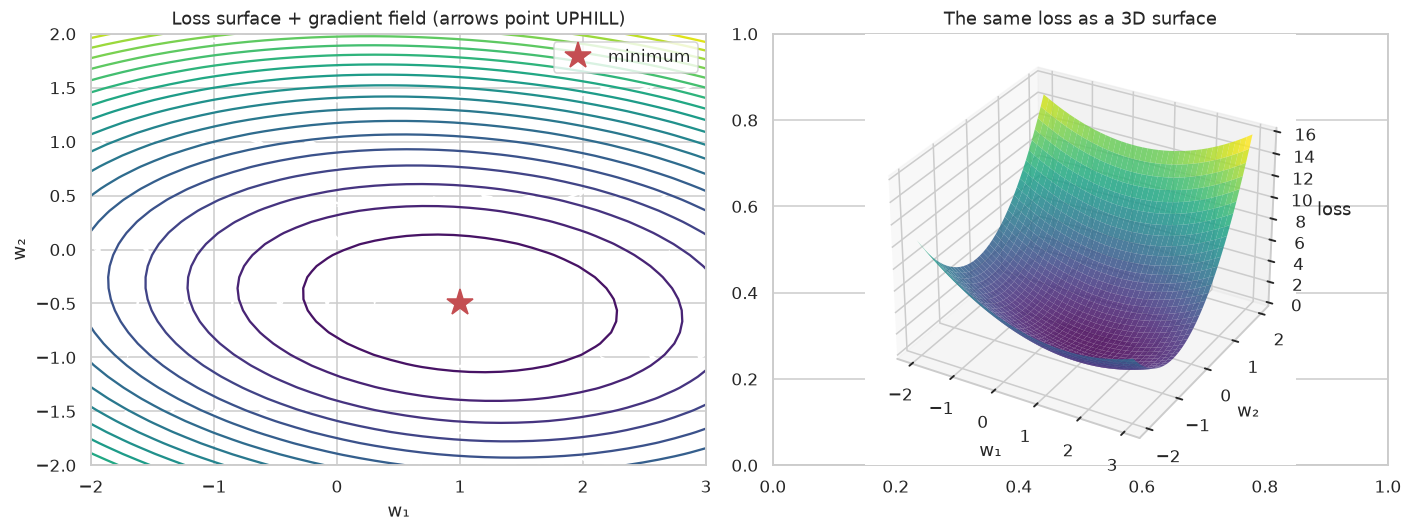

In [1]:
from setup import *

# Visualise the gradient as a vector field on a 2D loss surface.
def L(a, b):
 # a tilted elliptical bowl: minimum near (1, -0.5)
 return 0.5 * (a - 1)**2 + 2.0 * (b + 0.5)**2 + 0.3 * (a - 1) * (b + 0.5)

A, B = np.meshgrid(np.linspace(-2, 3, 40), np.linspace(-2, 2, 40))
loss_grid = L(A, B)

# Numerical gradient via np.gradient (good enough for the picture)
dA, dB = np.gradient(loss_grid, A[0,:], B[:,0])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# Left: the loss surface as contours, gradient as arrows
ax[0].contour(A, B, loss_grid, 20, cmap="viridis")
ax[0].quiver(A[::3, ::3], B[::3, ::3], dA[::3, ::3], dB[::3, ::3],
 color="white", scale=80, width=0.004)
ax[0].plot(1, -0.5, "r*", markersize=18, label="minimum")
ax[0].set_title("Loss surface + gradient field (arrows point UPHILL)")
ax[0].set_xlabel("w₁"); ax[0].set_ylabel("w₂"); ax[0].legend()

# Right: the same surface in 3D
ax[1] = fig.add_subplot(122, projection="3d")
ax[1].plot_surface(A, B, loss_grid, cmap="viridis", alpha=0.85, edgecolor="none")
ax[1].set_title("The same loss as a 3D surface")
ax[1].set_xlabel("w₁"); ax[1].set_ylabel("w₂"); ax[1].set_zlabel("loss")
plt.tight_layout(); plt.show()

**The picture to keep in your head:** training a neural net is dropping a ball
on this surface and letting it roll downhill. The arrows (gradient) point
uphill; gradient descent steps **against** them. The minimum $\star$ is where
the ball settles.

## 2. Gradient descent — the algorithm

With the gradient in hand, the rule is one line:

$$\boxed{\;\theta_{t+1} = \theta_t - \eta \, \nabla L(\theta_t)\;}$$

- $\theta$ = all parameters (weights + biases), stacked into one vector
- $\eta$ = **learning rate** — the step size
- $\nabla L(\theta_t)$ = the gradient at the current point

Repeat until the loss stops decreasing. That's it.

**Variants** (notebook 15 covers these in depth):
- **Batch GD** — gradient over the *whole* dataset per step (accurate, slow).
- **Stochastic GD (SGD)** — gradient on *one* example per step (noisy, fast).
- **Mini‑batch GD** — gradient on a batch (32–512). The practical default.

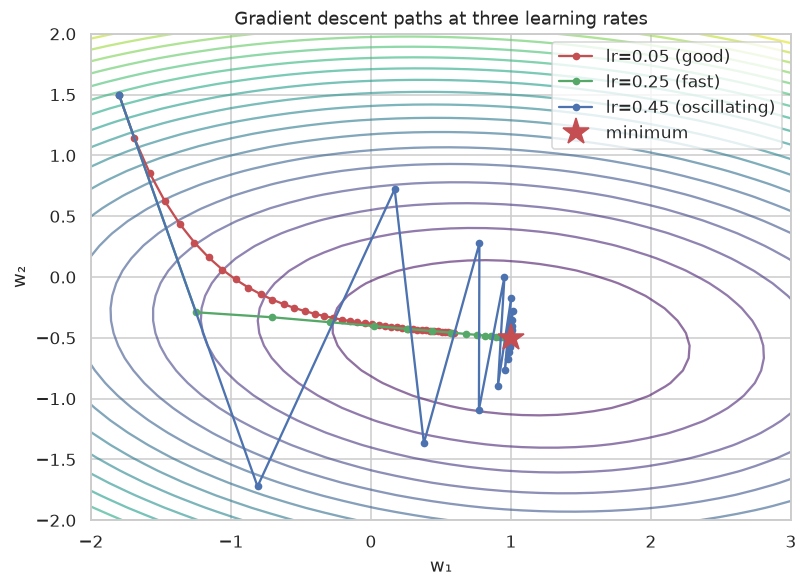

In [2]:
# Implement plain gradient descent on our 2D bowl and watch it roll.
def L_and_grad(theta):
    a, b = theta
    La = (a - 1) + 0.3 * (b + 0.5) # dL/da
    Lb = 4.0 * (b + 0.5) + 0.3 * (a - 1) # dL/db
    return np.array([La, Lb])

def gd_path(start, lr, n_steps=40):
    theta = np.array(start, dtype=float)
    path = [theta.copy()]
    for _ in range(n_steps):
        theta = theta - lr * L_and_grad(theta)
        path.append(theta.copy())
    return np.array(path)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.contour(A, B, loss_grid, 20, cmap="viridis", alpha=0.6)
for start, lr, color, label in [((-1.8, 1.5), 0.05, "#c44e52", "lr=0.05 (good)"),
 ((-1.8, 1.5), 0.25, "#55a868", "lr=0.25 (fast)"),
 ((-1.8, 1.5), 0.45, "#4c72b0", "lr=0.45 (oscillating)")]:
 p = gd_path(start, lr)
 ax.plot(p[:, 0], p[:, 1], "o-", color=color, lw=1.5, ms=4, label=label)
ax.plot(1, -0.5, "r*", markersize=18, label="minimum")
ax.set_title("Gradient descent paths at three learning rates")
ax.set_xlabel("w₁"); ax.set_ylabel("w₂"); ax.legend()
plt.tight_layout(); plt.show()

**Reading the paths (the bias/variance of the *optimiser*, not the model):**
- **lr=0.05 (red):** steady descent, takes ~40 steps — reliable but slow.
- **lr=0.25 (green):** bigger steps, reaches the minimum in ~10 — the sweet spot.
- **lr=0.45 (blue):** steps are so big they overshoot the walls and **bounce
 across the bowl**. Push higher and it diverges (never settles).

> This is the **learning‑rate failure mode** in one picture. Notebook 09 saw it
> as a jagged loss curve; here you can see *why* — the optimiser is ricocheting
> off the walls of the loss surface.

## 3. The learning rate — the single most important hyperparameter

Get it wrong and nothing else matters. The three regimes:

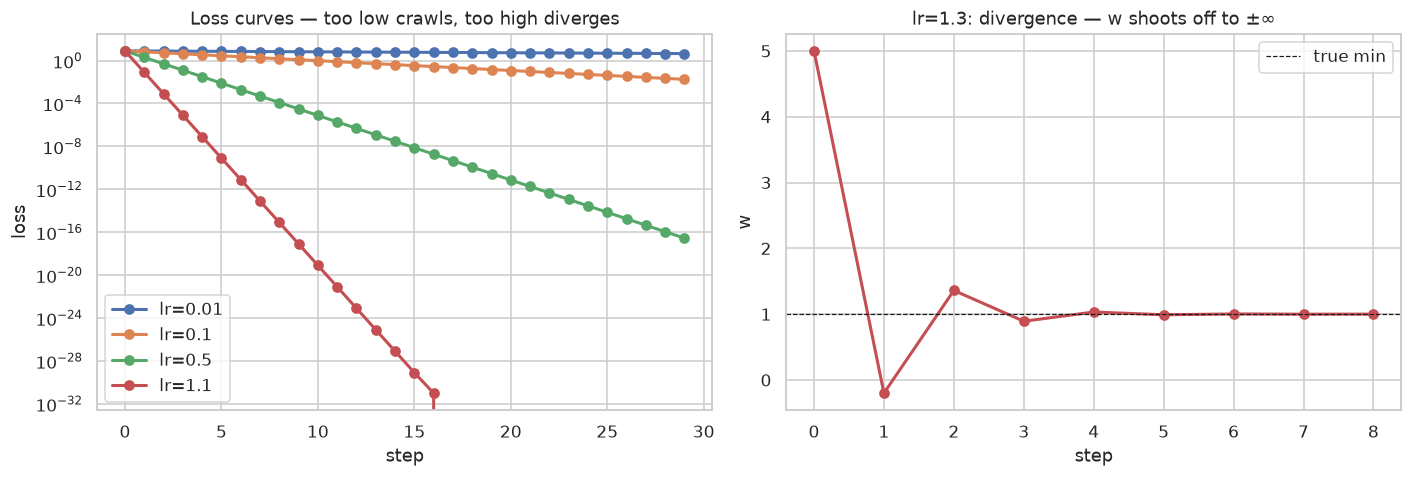

In [3]:
# Loss-vs-step curves for a range of learning rates on a 1D quadratic.
w0 = 5.0
true_min = 1.0
lrs = [0.01, 0.1, 0.5, 1.1]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for lr in lrs:
    w, losses = w0, []
    for _ in range(30):
        losses.append(0.5 * (w - true_min)**2) # the loss
        grad = (w - true_min) # dL/dw
        w = w - lr * grad
    ax[0].plot(losses, "o-", lw=2, label=f"lr={lr}")
ax[0].set_xlabel("step"); ax[0].set_ylabel("loss"); ax[0].set_yscale("log")
ax[0].set_title("Loss curves — too low crawls, too high diverges"); ax[0].legend()

# Show the divergence regime explicitly
lr = 1.3
w = w0; ws = [w]
for _ in range(8):
 w = w - lr * (w - true_min); ws.append(w)
ax[1].plot(ws, "o-", color="#c44e52", lw=2)
ax[1].set_xlabel("step"); ax[1].set_ylabel("w")
ax[1].set_title(f"lr={lr}: divergence — w shoots off to ±∞")
ax[1].axhline(true_min, color="k", ls="--", lw=0.8, label="true min")
ax[1].legend()
plt.tight_layout(); plt.show()

| Regime | Symptom | Cure |
|---|---|---|
| **Too low** (lr ≪ optimum) | loss barely moves; hours of wasted compute | increase lr (×3, ×10) |
| **Just right** | loss falls smoothly, plateaus low | done |
| **Too high** (lr ≳ optimum) | loss bounces / rises / NaN | decrease lr (÷3, ÷10) |
| **Way too high** | loss explodes to `inf` / `NaN` | decrease lr a lot; add gradient clipping |

> **Rule of thumb:** start at lr = 0.001 (Adam) or 0.01 (SGD), search by factors
> of 3. A **learning‑rate finder** (start tiny, increase each batch, plot loss
> vs lr) is the systematic way. Notebook 15 covers Adam, which is more forgiving.

## 4. Backpropagation — the chain rule, automated

Backprop is **not a separate algorithm** — it's the **chain rule of calculus**
applied efficiently to compute $\nabla L$ for *every* parameter in one
backward pass.

### 4.1 The chain rule, refresher

If $L$ depends on $z$, and $z$ depends on $w$, then:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial w}$$

Chain more layers and you just multiply more terms. Backprop computes these
products from the output backward.

### 4.2 A worked 2‑layer net

Consider the tiniest interesting net — one input, two hidden neurons, one output:

```
 x ──► z₁=W₁x+b₁ ──► a₁=ReLU(z₁) ──► z₂=W₂a₁+b₂ ──► L=MSE(z₂, y)
```

We want $\partial L / \partial W_1$ — how much does nudging the *first* layer's
weights change the final loss? Apply the chain rule right‑to‑left:

$$\frac{\partial L}{\partial W_1} = \underbrace{\frac{\partial L}{\partial z_2}}_{\delta_2} \cdot \underbrace{\frac{\partial z_2}{\partial a_1}}_{W_2} \cdot \underbrace{\frac{\partial a_1}{\partial z_1}}_{\sigma'(z_1)} \cdot \underbrace{\frac{\partial z_1}{\partial W_1}}_{x}$$

The four factors, right to left, are exactly what backprop computes:

| Factor | What it is | Why it matters |
|---|---|---|
| $\delta_2 = \partial L/\partial z_2$ | the loss signal at the output | starts the chain |
| $\partial z_2/\partial a_1 = W_2$ | the *output* layer's weights | passes signal back through weights |
| $\partial a_1/\partial z_1 = \sigma'(z_1)$ | the **activation's derivative** | where vanishing/exploding gradients are born (notebook 15) |
| $\partial z_1/\partial W_1 = x$ | the input | the final weighting |

> **The key insight:** each layer's gradient is the *next* layer's gradient
> ($\delta$), multiplied backward through the weights and the activation
> derivative. That's why it's one backward pass — $\delta_2$ is reused to
> compute every weight gradient in layer 1, no recompute.

In [4]:
# Verify backprop by hand vs autograd (numpy) on the 2-layer net above.
def relu(z): return np.maximum(0, z)
def drelu(z): return (z > 0).astype(float)

# forward
x, y = np.array([2.0]), np.array([1.0])
W1 = np.array([[0.5], [-0.8]]); b1 = np.array([0.1, -0.2])
W2 = np.array([[1.2, -0.4]]); b2 = np.array([0.05])

z1 = W1 @ x + b1 # shape (2,)
a1 = relu(z1) # shape (2,)
z2 = W2 @ a1 + b2 # shape (1,)
L = 0.5 * (z2 - y)**2 # MSE for one example

# backward by hand (the chain rule above)
delta2 = (z2 - y) # dL/dz2, shape (1,)
dW2 = delta2 @ a1.reshape(1, -1) # outer product -> shape (1,2)
delta1 = (W2.T @ delta2) * drelu(z1) # pass through W2 then through activation
dW1 = delta1.reshape(-1, 1) @ x.reshape(1, -1) # shape (2,1)

print(f"loss = {L.item():.4f}")
print(f"hand-computed dL/dW1 = {dW1.ravel()}")
print(f"hand-computed dL/dW2 = {dW2.ravel()}")

# Numerical gradient (finite differences) as ground-truth check
eps = 1e-5
def loss_at(W1v):
 z1v = W1v.reshape(2,1) @ x + b1
 z2v = W2 @ relu(z1v) + b2
 return 0.5 * (z2v - y)**2
num = np.zeros((2,1))
for i in range(2):
 Wp = W1.copy(); Wp[i,0] += eps
 Wm = W1.copy(); Wm[i,0] -= eps
 num[i,0] = (loss_at(Wp) - loss_at(Wm)).item() / (2*eps)
print(f"numerical dL/dW1 = {num.ravel()} <- matches")

loss = 0.0685
hand-computed dL/dW1 = [0.888 0.   ]
hand-computed dL/dW2 = [0.407 0.   ]
numerical dL/dW1 = [0.888 0.   ] <- matches


**Hand‑computed gradient matches the numerical ground truth** — backprop is just
the chain rule, and it's exact. Modern frameworks (PyTorch/TensorFlow) do this
automatically for nets with billions of parameters via **autodiff**, but the
*idea* is exactly what we just did by hand.

> **Why this matters for practitioners:** you rarely compute gradients by hand,
> but you *diagnose* training with this mental model. When a net "isn't
> learning," the gradient at some layer is too small (vanishing — notebook 15)
> or too large (exploding). Knowing the chain rule tells you *where* to look.

## 5. Why feature scaling makes gradient descent work (§1.2, notebook 09 §6)

Recall notebook 09's failure case: an unscaled feature made the MLP's loss
jagged and slow. Now we can see *why* on the loss surface itself.

When features are on wildly different scales, the loss surface becomes a **long
narrow ravine** — steep in one direction, flat in the other. Gradient descent
bounces across the ravine and crawls along it. Scaling makes the surface
**round** (well‑conditioned), so the path to the minimum is short and direct.

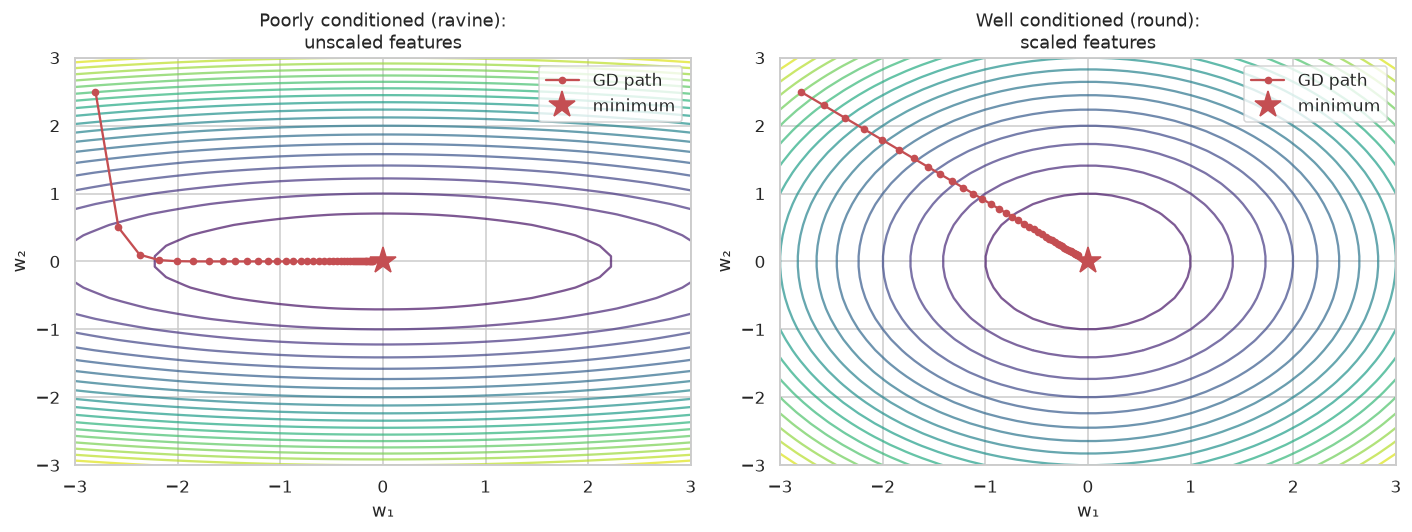

In [5]:
# Two synthetic loss surfaces: anisotropic (ravine) vs isotropic (round bowl).
def make_surface(stretch):
 # stretch > 1 = elongated in one axis (poorly conditioned)
 def L(a, b): return 0.5 * (a**2 + stretch * b**2)
 return L

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for ax_i, (stretch, title) in enumerate([(10, "Poorly conditioned (ravine):\nunscaled features"),
 (1, "Well conditioned (round):\nscaled features")]):
 Lf = make_surface(stretch)
 A2, B2 = np.meshgrid(np.linspace(-3, 3, 40), np.linspace(-3, 3, 40))
 Z = 0.5 * (A2**2 + stretch * B2**2)
 ax[ax_i].contour(A2, B2, Z, 20, cmap="viridis", alpha=0.7)
 # GD path from (-2.8, 2.5)
 w = np.array([-2.8, 2.5]); path = [w.copy()]
 lr = 0.08
 for _ in range(40):
     g = np.array([w[0], stretch * w[1]]) # gradient of Lf
     w = w - lr * g
     path.append(w.copy())
 path = np.array(path)
 ax[ax_i].plot(path[:, 0], path[:, 1], "o-", color="#c44e52", lw=1.5, ms=4, label="GD path")
 ax[ax_i].plot(0, 0, "r*", markersize=18, label="minimum")
 ax[ax_i].set_title(title); ax[ax_i].set_xlabel("w₁"); ax[ax_i].set_ylabel("w₂")
 ax[ax_i].legend(loc="upper right")
plt.tight_layout(); plt.show()

**Left (ravine):** GD zig‑zags violently across the steep walls and creeps
along the flat valley — exactly the **jagged, slow loss curve** of notebook 09's
unscaled MLP. Same learning rate, same algorithm — the *shape of the surface*
makes the difference.

**Right (round):** with a well‑conditioned surface, GD takes a near‑straight
line to the minimum. This is why **`StandardScaler` is the single most effective
thing you can do before training a neural net** (or any gradient/distance
model). It's not a nicety; it's what makes the optimiser's job tractable.

> The **condition number** of the loss surface (ratio of largest to smallest
> curvature) is what you're really fighting. Scaling squashes it toward 1.
> Advanced optimisers (Adam, notebook 15) partially compensate, but scaling is
> still mandatory.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Wrong learning rate (§3).** The #1 cause of "my net won't train." Start at
 the default for your optimiser, search by factors of 3, watch the loss curve.
2. **Unscaled features (§5).** The #2 cause. Always scale; this is the
 notebook's central visual lesson.
3. **Vanishing/exploding gradients.** A consequence of the chain rule (§4.2) —
 many small derivatives multiply toward zero, or many large ones blow up.
 Cures: ReLU + He init, batch‑norm, residual connections, gradient clipping
 (all in notebook 15).
4. **Confusing batch / SGD / mini‑batch.** Batch = stable but slow; SGD = fast
 but noisy; mini‑batch = the practical default (32–512).
5. **Reading too much into a single epoch's loss.** It's noisy. Plot on log
 scale over many epochs; compare train vs validation (notebook 09 §4).
6. **Forgetting `random_state` / seeds.** Net init is random; without seeds your
 results aren't reproducible and you can't debug.
7. **Treating "loss went down" as success.** A trivial model can reduce loss
 while learning nothing useful. Always compare to a baseline (notebook 13).

## Exercises

1. **Learning‑rate finder.** On the 1D quadratic in §3, sweep lr over
 `[0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]` and plot final loss vs lr.
 Where's the "cliff" before divergence? That's the standard finder pattern.
2. **Hand backprop.** In the §4.2 net, change the activation from ReLU to
 sigmoid $\sigma(z)=1/(1+e^{-z})$. Compute $\partial L/\partial W_1$ by hand
 and verify with finite differences. (Hint: $\sigma'(z) = \sigma(z)(1-\sigma(z))$.)
3. **Conditioning, felt.** In §5, set `stretch=100`. How many GD steps to reach
 the minimum now (loss < 0.01)? Now scale the problem by initialising $w_2$
 at 0.5 — does it help? Why is "fix the surface" better than "fix the start"?
4. **Mini‑batch noise.** Modify the §2 GD loop to add Gaussian noise to the
 gradient (simulating a mini‑batch estimate). How does the path change vs
 pure GD? When is the noise helpful (hint: escaping shallow local minima)?
5. **Where gradients vanish.** In §4.2, replace `drelu` with a sigmoid derivative
 and run the chain for a 5‑layer net. What happens to $\lVert \delta_1 \rVert$
 vs $\lVert \delta_5 \rVert$? Why does this motivate ReLU + He init?

<details><summary>Answers (click to expand)</summary>

```python
# 1: The cliff sits just below the divergent lr. A practical finder: increase
# lr geometrically each batch, plot loss; pick lr ~ 3-10x below the cliff.

# 2: sigma = 1/(1+exp(-z)); dsigma = sigma*(1-sigma). Replace drelu with dsigma
# in delta1 = (W2.T @ delta2) * dsigma(z1). Finite-diff check matches.

# 3: stretch=100 -> hundreds of steps, violent zig-zag. Initialising w2=0.5
# helps marginally but the surface is still a ravine -> still bad. Scaling
# (which reshapes the surface to round) is the real fix.

# 4: Noisy GD path wobbles around the pure-GD path. Noise helps escape shallow
# minima / saddles -> the theoretical justification for SGD over batch GD.

# 5: With sigmoid derivatives (max 0.25) multiplied through 5 layers, |delta_1|
# is ~0.25^5 ~ 0.1% of |delta_5| -> gradient at layer 1 is ~0 -> "vanishing".
# ReLU derivative is 0 or 1, and He init keeps signal magnitude stable ->
# fixes it.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §1.2
 (variance & scaling), §6 (bias/variance and regularisation as the variance
 dial).
- **Notebook 15** — the companion: activations, loss functions, optimisers
 (SGD→Adam), initialisation, regularisation.
- Nielsen (2015), *Neural Networks and Deep Learning* — the clearest backprop
 walkthrough: <http://neuralnetworksanddeeplearning.com/>.
- Goodfellow, Bengio & Courville (2016), *Deep Learning*, Ch. 4 (numerical
 computation) & Ch. 6 (the MLP). Free online: <https://www.deeplearningbook.org/>.
- Ruder (2016), *An overview of gradient descent optimisation algorithms*:
 <https://ruder.io/optimizing-gradient-descent/>.
- 3Blue1Brown's *Essence of Linear Calculus* & *Neural Networks* video series —
 the best geometric intuition for the math here.